# 01 — Embedding sanity check

Phase 1 validation gate. Do the learned audio embeddings (MERT, CLAP) place
tracks in a space where *similar music sits together*? We UMAP-project the
song embeddings to 2-D and colour by genre.

Three panels: **MERT (raw)**, **MERT (mean-centred)** — testing whether
removing the anisotropic common component helps — and **CLAP**.

Genre labels come from **Last.fm artist tags** (Spotify's catalogue endpoints
are 403 for a Development-mode app since the 2026 platform-security changes).

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from dotenv import load_dotenv
from sqlmodel import select

from core import paths
from core.config import load_config
from storage import db, vectors
from storage.schema import Track

load_dotenv(paths.PROJECT_ROOT / ".env")
cfg = load_config()

C:\Users\rbash\Dropbox\Upwork\playground\projects\my-song\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load embeddings + track metadata

In [2]:
mert = vectors.read_embeddings(vectors.song_embedding_path(cfg, "mert_song"))
clap = vectors.read_embeddings(vectors.song_embedding_path(cfg, "clap_song"))
track_ids = sorted(set(mert) & set(clap))
print(f"{len(track_ids)} tracks with both MERT + CLAP embeddings")

with db.session_scope(cfg) as session:
    # Pull plain values inside the session — ORM objects detach once it closes.
    meta = {
        t.id: {"artist": t.artist, "title": t.title}
        for t in session.exec(select(Track).where(Track.id.in_(track_ids))).all()
    }

df = pd.DataFrame([{"track_id": t, **meta[t]} for t in track_ids])
mert_mat = np.stack([mert[t].embedding for t in track_ids])
clap_mat = np.stack([clap[t].embedding for t in track_ids])
print(f"MERT matrix {mert_mat.shape}, CLAP matrix {clap_mat.shape}")

119 tracks with both MERT + CLAP embeddings
MERT matrix (119, 1024), CLAP matrix (119, 512)


## Cosine-similarity spread

A wide spread means the space discriminates tracks; a narrow one (anisotropy)
means raw cosine barely separates anything.

In [3]:
def cosine_spread(matrix: np.ndarray) -> str:
    unit = matrix / np.linalg.norm(matrix, axis=1, keepdims=True)
    sim = (unit @ unit.T)[np.triu_indices(len(matrix), 1)]
    return f"min={sim.min():.3f}  mean={sim.mean():.3f}  max={sim.max():.3f}"


mert_centred = mert_mat - mert_mat.mean(axis=0, keepdims=True)
print("MERT raw     ", cosine_spread(mert_mat))
print("MERT centred ", cosine_spread(mert_centred))
print("CLAP         ", cosine_spread(clap_mat))

MERT raw      min=0.932  mean=0.979  max=0.995
MERT centred  min=-0.736  mean=-0.008  max=0.746
CLAP          min=0.548  mean=0.871  max=0.982


## Genre labels — Last.fm artist tags (cached to disk)

In [4]:
df["primary_artist"] = df["artist"].str.split(",").str[0].str.strip()

tag_cache = paths.resolve(cfg.paths.features) / "lastfm_tags.json"
artist_tags: dict[str, list[str]] = {}
if tag_cache.exists():
    artist_tags = json.loads(tag_cache.read_text())

missing = [a for a in sorted(df["primary_artist"].unique()) if a not in artist_tags]
if missing:
    from acquisition.lastfm import LastfmClient

    client = LastfmClient()
    for artist in missing:
        artist_tags[artist] = client.artist_tags(artist, limit=5)
    tag_cache.parent.mkdir(parents=True, exist_ok=True)
    tag_cache.write_text(json.dumps(artist_tags, indent=0))

df["genre"] = df["primary_artist"].map(
    lambda a: (artist_tags.get(a) or ["unknown"])[0]
)
print(f"genre tag present for {(df['genre'] != 'unknown').sum()}/{len(df)} tracks")

# Colour by the 8 most common genres; everything else collapses to "other".
top = df["genre"].value_counts().head(8).index
df["label"] = df["genre"].where(df["genre"].isin(top), "other")
print(df["label"].value_counts())

genre tag present for 101/119 tracks
label
other        35
rnb          28
unknown      18
hip-hop      12
soul          7
pakistan      7
hip hop       5
trap          4
free jazz     3
Name: count, dtype: int64


## UMAP projections

In [5]:
def project(matrix: np.ndarray, seed: int = 42) -> np.ndarray:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, len(matrix) - 1),
        min_dist=0.1,
        metric="cosine",
        random_state=seed,
    )
    return reducer.fit_transform(matrix)


projections = [
    ("MERT (raw)", project(mert_mat)),
    ("MERT (mean-centred)", project(mert_centred)),
    ("CLAP", project(clap_mat)),
]

C:\Users\rbash\Dropbox\Upwork\playground\projects\my-song\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\rbash\Dropbox\Upwork\playground\projects\my-song\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\rbash\Dropbox\Upwork\playground\projects\my-song\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Plot — UMAP coloured by genre

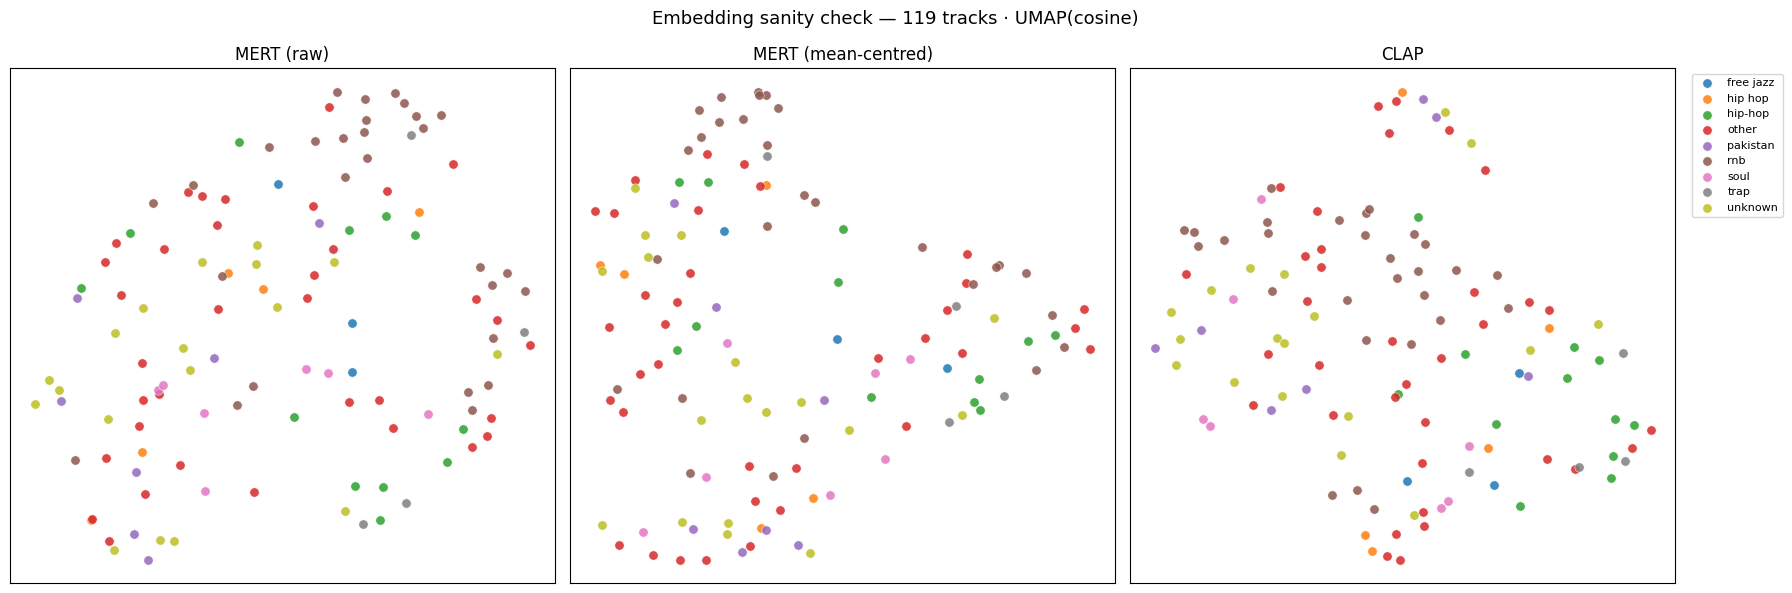

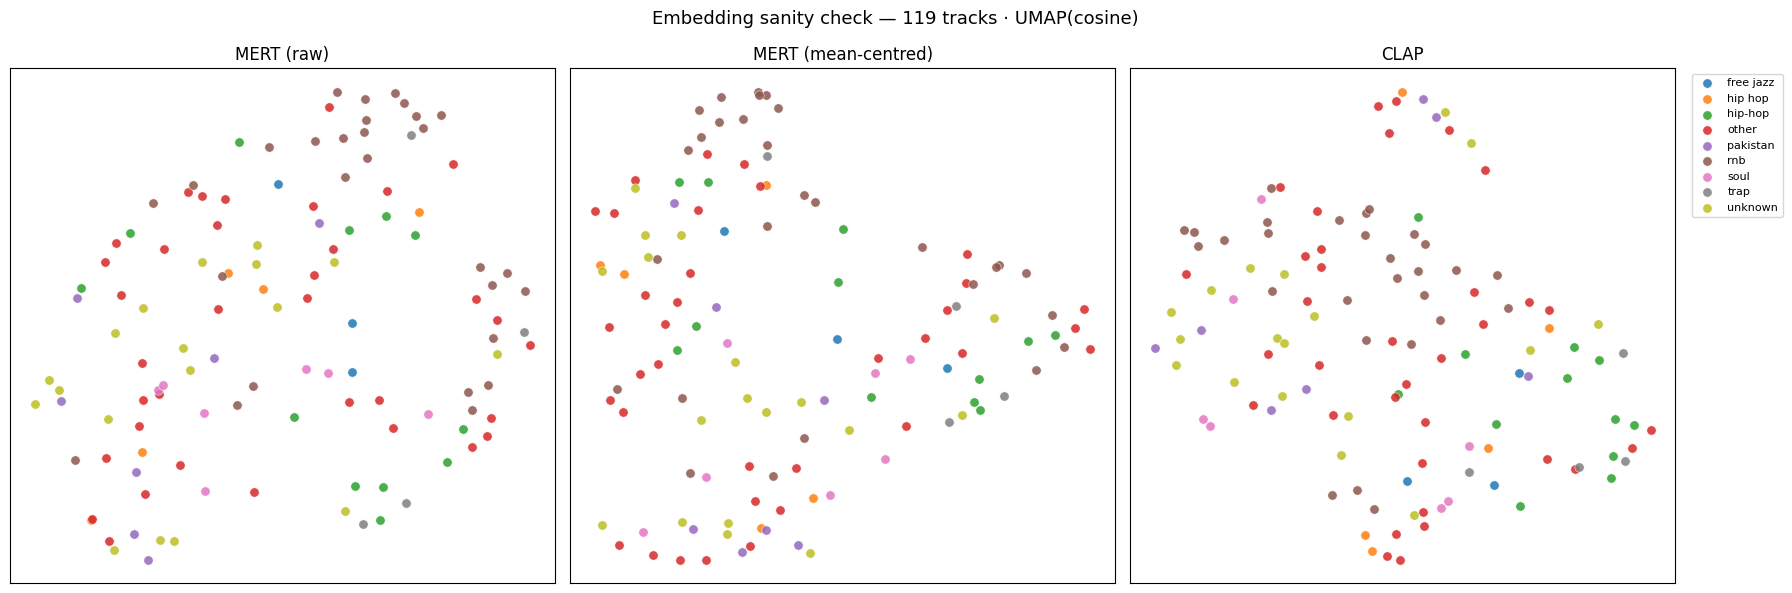

In [6]:
categories = sorted(df["label"].unique())
cmap = plt.get_cmap("tab10")
colours = {c: cmap(i % 10) for i, c in enumerate(categories)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, xy) in zip(axes, projections, strict=True):
    for category in categories:
        mask = (df["label"] == category).to_numpy()
        ax.scatter(
            xy[mask, 0], xy[mask, 1], s=45, color=colours[category],
            label=category, alpha=0.85, edgecolor="white", linewidth=0.4,
        )
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
axes[-1].legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8)
fig.suptitle(f"Embedding sanity check — {len(df)} tracks · UMAP(cosine)", fontsize=13)
fig.tight_layout()
fig.savefig(
    paths.PROJECT_ROOT / "notebooks" / "01_embedding_sanity.png",
    dpi=110,
    bbox_inches="tight",
)
fig  # last expression — embeds the plot when run as a notebook cell

## Nearest-neighbour probe

Genre-colour clustering is a weak test on a genre-homogeneous library. A more
direct "essence" check — and exactly what M1 will do — is to look at each
track's nearest neighbours by embedding cosine. Do they *make sense*?

In [7]:
labels = (df["artist"] + " — " + df["title"]).tolist()


def neighbours(matrix: np.ndarray, idx: int, k: int = 5) -> list[tuple[int, float]]:
    unit = matrix / np.linalg.norm(matrix, axis=1, keepdims=True)
    sims = unit @ unit[idx]
    order = np.argsort(-sims)
    return [(int(j), float(sims[j])) for j in order if j != idx][:k]


rng = np.random.default_rng(0)
for idx in rng.choice(len(df), size=5, replace=False):
    print(f"\nQUERY  {labels[idx]}")
    for space, matrix in (("centred-MERT", mert_centred), ("CLAP", clap_mat)):
        print(f"  {space}:")
        for j, sim in neighbours(matrix, int(idx)):
            print(f"    {sim:.3f}  {labels[j]}")


QUERY  Kyle Dion — Tears On A Pretty Face
  centred-MERT:
    0.518  ZXKAI, slxughter — NO BATIDÃO
    0.500  The Weeknd — A Lonely Night
    0.482  The Weeknd, Justice — Wake Me Up (feat. Justice)
    0.478  Arctic Monkeys — Do I Wanna Know?
    0.478  Maanu, MALIK. — cm
  CLAP:
    0.962  Samad Khan, Crustacean — Faza
    0.960  Kunwarr, Dishant — Euphoria
    0.955  HYDR, PDNY — Fiza
    0.954  The Weeknd — A Lonely Night
    0.954  Travis Scott, Kacy Hill — 90210 (feat. Kacy Hill)

QUERY  Playboi Carti, The Weeknd — RATHER LIE (with The Weeknd)
  centred-MERT:
    0.562  The Weeknd, Lana Del Rey — The Abyss (feat. Lana Del Rey)
    0.536  The Weeknd — Cry For Me
    0.487  Abdul Hannan, TEDD — Changiyaan
    0.446  ZXKAI, slxughter — NO BATIDÃO
    0.442  Travis Scott, Future, 2 Chainz — 3500 (feat. Future & 2 Chainz)
  CLAP:
    0.961  Abdul Hannan, Maanu, Shahmeer Raza Khan — Qasmein
    0.958  Hassan & Roshaan — hota hai kya?
    0.958  HYDR, PDNY — Aik Wari
    0.955  Gravero,

## Observations

- **Anisotropy is real and fixable.** Raw MERT cosine sits in a narrow
  ~0.93–0.99 cone; mean-centring spreads it to roughly −0.74…0.75. M1 must
  centre MERT embeddings before cosine ranking.
- **Genre-colour clusters are faint** — but this library is genre-homogeneous
  (rnb / hip-hop / soul / trap dominate; ~half the tracks are "other"/
  "unknown"), so colour separation is not a fair test here.
- The **nearest-neighbour probe** is the signal to read: if a track's top
  cosine neighbours are plausibly "similar music", the embeddings capture
  real structure — the Phase 1 hypothesis survives its first check.
- Re-run on a deliberately genre-diverse track sample for a stronger
  colour-cluster test.